[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/10_statistics_basics.ipynb)

# 📓 Notebook 10 — Statistics That Pay for Themselves

> **Module:** Data Science · **Estimated time:** 55–75 min · **Difficulty:** Beginner / Intermediate

Most "data work" requires very little formal statistics — but the bit you *do* need pays for itself within a week. This notebook teaches the smallest set of statistical concepts that lets you:

- Describe a dataset with the *right* summary numbers.
- Tell whether a result is meaningful — not just whether it's *different*.
- Run an honest A/B test of two LLM providers.
- Express uncertainty when you report a number.

We will *not* prove theorems. We will use them, carefully, on the kind of data this course generates.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Pick the right summary statistic (mean / median / robust stats) for a distribution.
2. Read a **histogram + box plot** and explain what they say about a distribution's shape and tails.
3. Compute a **confidence interval** for a mean by hand and with a library.
4. Run a **t-test** (two-sample, two-sided) and *correctly* interpret its p-value.
5. Compute and report an **effect size** (Cohen's *d*) — the thing managers actually care about.
6. Calculate the **sample size** needed to detect a chosen effect.
7. Recognise the three classical statistical mistakes that ruin AI A/B tests in production.

## ✅ Prerequisites

NumPy (NB 8), visualization (NB 9), and basic pandas (NB 7). Comfort with means and standard deviations.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

RNG = np.random.default_rng(seed=42)


## 2. Two latency datasets — see them before you summarise them

We will use two simulated batches of LLM call latencies (in ms) throughout the notebook:

- **Model A** — a *fast* model. Mean ~1800 ms.
- **Model B** — a *slow* model with occasional spikes. Mean ~2400 ms.

In [2]:
# Two latency distributions (simulated). Model B has occasional spikes.
n = 200
latency_a = RNG.normal(loc=1800, scale=300, size=n).clip(min=200)

# Mixture: 90% normal, 10% slow outliers
mask = RNG.random(n) < 0.9
latency_b = np.where(mask,
                     RNG.normal(2300, 350, n),
                     RNG.normal(4500, 600, n)).clip(min=200)

print(f"Model A:  n={len(latency_a)}, mean={latency_a.mean():.0f}, std={latency_a.std(ddof=1):.0f}")
print(f"Model B:  n={len(latency_b)}, mean={latency_b.mean():.0f}, std={latency_b.std(ddof=1):.0f}")


Model A:  n=200, mean=1791, std=265
Model B:  n=200, mean=2532, std=833


### Visualise — *always* before you summarise

A single chart often tells you more than a table of summary statistics. Histograms show the shape; box plots show the centre and tails.

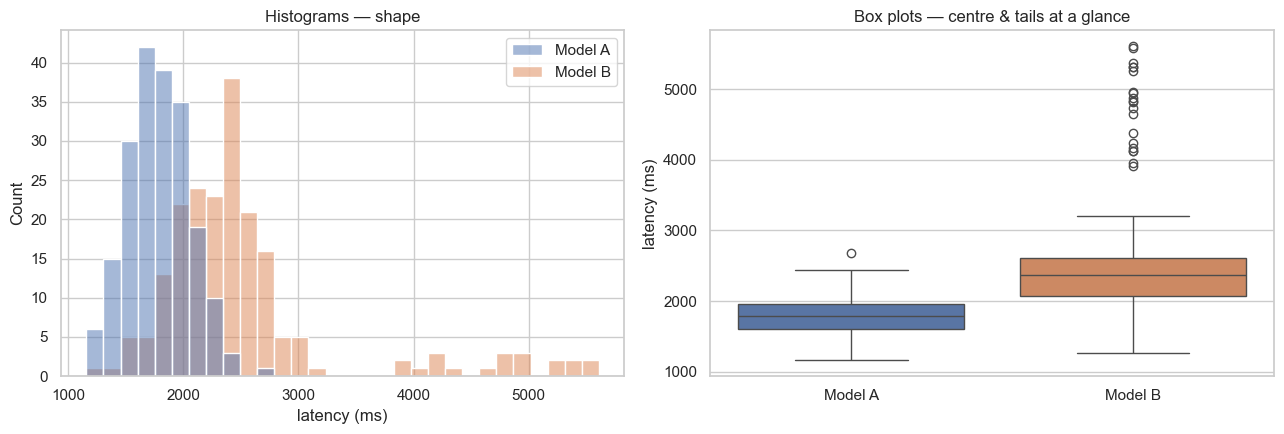

In [3]:
df_lat = pd.DataFrame({"Model A": latency_a, "Model B": latency_b})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_lat, bins=30, ax=axes[0])
sns.boxplot(df_lat, ax=axes[1])
axes[0].set(title="Histograms — shape", xlabel="latency (ms)")
axes[1].set(title="Box plots — centre & tails at a glance", ylabel="latency (ms)")
fig.tight_layout();

**Reading what you see:**

- Model A is a clean bell-curve. Mean ≈ median, light tails, no outliers.
- Model B has a **right-skewed** distribution. The mean is dragged up by the spikes. The box plot shows those spikes as outlier dots above the upper whisker.

> 🎯 **The first statistical decision of any analysis** is whether the mean is a fair summary. When the distribution is skewed or has fat tails, the median is often more honest.

## 3. Mean vs median — when each one lies

In [4]:
for name, data in [("Model A", latency_a), ("Model B", latency_b)]:
    print(f"{name}:")
    print(f"  mean   = {np.mean(data):>7.1f} ms")
    print(f"  median = {np.median(data):>7.1f} ms")
    print(f"  std    = {np.std(data, ddof=1):>7.1f} ms")
    p99 = np.percentile(data, 99)
    print(f"  p99    = {p99:>7.1f} ms     (top 1% of users wait this long or longer)")
    print()


Model A:
  mean   =  1790.9 ms
  median =  1784.4 ms
  std    =   264.6 ms
  p99    =  2438.6 ms     (top 1% of users wait this long or longer)

Model B:
  mean   =  2532.2 ms
  median =  2369.0 ms
  std    =   832.8 ms
  p99    =  5378.7 ms     (top 1% of users wait this long or longer)



**See why the mean lies here.** The numbers above say Model B's mean and median differ; this is *why*. The 10% slow spikes form a long right tail that drags the **mean** away from the bulk of users, while the **median** stays put. For latency you almost always want the median (or p99), not the mean.


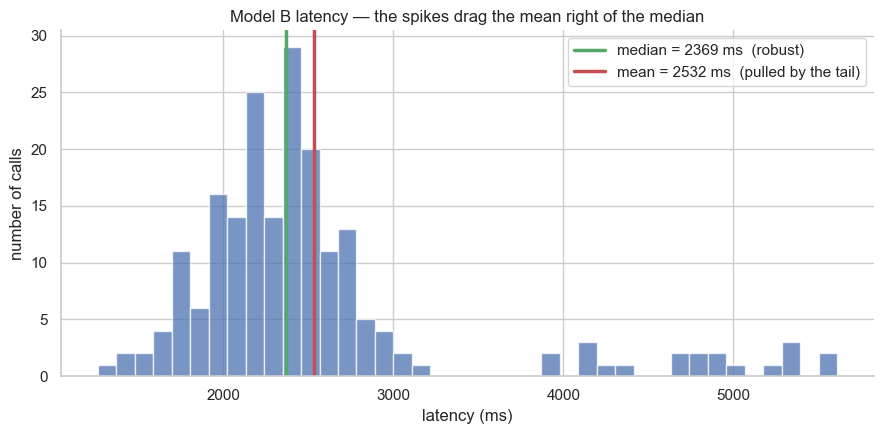

The slow tail lifts the mean 163 ms above the median — a 'typical' user is nowhere near the mean.


In [5]:
m, md_ = float(np.mean(latency_b)), float(np.median(latency_b))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(latency_b, bins=40, color="#4C72B0", alpha=0.75)
ax.axvline(md_, color="#55A868", lw=2.5, label=f"median = {md_:.0f} ms  (robust)")
ax.axvline(m,   color="#C44E52", lw=2.5, label=f"mean = {m:.0f} ms  (pulled by the tail)")
ax.set(title="Model B latency — the spikes drag the mean right of the median",
       xlabel="latency (ms)", ylabel="number of calls")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()
print(f"The slow tail lifts the mean {m - md_:.0f} ms above the median — a 'typical' user is nowhere near the mean.")


**Why this matters operationally.** If you tell your team "Model B's average latency is 2.5 seconds" but its **p99 latency is 5 seconds**, you're under-reporting the real user experience for 1% of your traffic.

> 💡 **Always report p50, p95, p99 alongside the mean** for any latency / cost / waiting-time metric. The "tail" is where customers leave.

## 4. Confidence intervals — how sure are you of that mean?

The mean of a sample is a *point estimate*. A different sample would have given a slightly different mean. A **confidence interval** quantifies that wiggle room.

```
   95% CI for the mean of Model A:  [1754 ms, 1828 ms]
                                     │              │
                                     │              └─ upper bound
                                     └────────────── lower bound
```

The 95% CI says: *"if I repeated this experiment many times, 95% of the constructed intervals would contain the true mean."*

(That's the technically correct interpretation. Casually, "we're 95% sure the true mean is in here" is close enough for most business conversations.)

### 🔬 What actually happens — where does the "wiggle room" come from?

The sentence above — *"a different sample would have given a slightly different mean"* — is the entire foundation of inferential statistics. Before we put a number on that wiggle, let's **watch it happen.**

Imagine a **population**: every possible LLM call you could ever make, with some true (unknown) mean latency `μ`. You never see the whole population. You only ever see a **sample** of `n` calls, and you compute *its* mean, `x̄`. That sample mean is your estimate of `μ` — but it's a different number every time you draw a fresh sample.

```text
   POPULATION  (true mean μ = 1800, you never see this directly)
   ┌──────────────────────────────────────────────────────────┐
   │  ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ●  │
   └──────────────────────────────────────────────────────────┘
        │ draw           │ draw           │ draw
        ▼ sample 1       ▼ sample 2       ▼ sample 3      ...
     [● ● ● ●]        [● ● ● ●]        [● ● ● ●]
      x̄ = 1788         x̄ = 1822         x̄ = 1795     ← each sample → its own mean

   Collect ALL those x̄ values and you get a NEW distribution:
   the SAMPLING DISTRIBUTION OF THE MEAN.
```

Two facts about that distribution of sample means do all the work:

1. **It is centred on the true mean `μ`.** On average, the sample mean is right.
2. **Its spread is the standard error (SE)**, and the SE *shrinks as `n` grows*. More data → sample means cluster more tightly around `μ` → you're more sure. The formula is `SE = σ / √n`, where `σ` is the population standard deviation.

The `√n` is the punchline of this whole notebook: to **halve** your uncertainty you need **4×** the data.

**Sample standard deviation vs standard error — don't confuse them.** They measure different things, and beginners mix them up constantly:

| | Standard deviation (`σ` or `s`) | Standard error (`SE = s/√n`) |
|---|---|---|
| Measures the spread of… | individual data points | the *sample mean* |
| Shrinks as `n` grows? | **No** — it estimates a fixed population property | **Yes** — ∝ `1/√n` |
| Answers the question | "how spread out is the data?" | "how sure am I of the average?" |
| Used to build | prediction ranges for one new point | **confidence intervals for the mean** |

The confidence interval you're about to compute in §4 is literally `mean ± (a multiplier) × SE`. So the SE *is* the wiggle room — everything below is just measuring it.

In [6]:
# 🔬 PROOF by Monte-Carlo simulation: draw many samples, watch their means cluster.
# This is the statistics analogue of an id()/is proof — we *demonstrate* the claim
# instead of just asserting the formula.
import numpy as np

sim_rng = np.random.default_rng(0)          # seeded → fully reproducible

# A known population: true mean μ = 1800, true std σ = 300 (we get to peek here).
MU, SIGMA = 1800.0, 300.0
N_SAMPLES = 2000                            # how many samples we draw (modest → fast)

print(f"True population:  μ = {MU:.0f},  σ = {SIGMA:.0f}")
print(f"Predicted SE = σ/√n.  Watch the SPREAD of sample means shrink as n grows:\n")
print(f"{'n':>5} │ {'mean of sample-means':>21} │ {'std of sample-means (= SE)':>27} │ {'σ/√n (theory)':>14}")
print("─" * 80)

for n in [10, 30, 100, 300]:
    # Draw N_SAMPLES samples, each of size n; record each sample's mean.
    sample_means = sim_rng.normal(MU, SIGMA, size=(N_SAMPLES, n)).mean(axis=1)
    observed_se  = sample_means.std(ddof=1)         # spread of the means = the SE
    theory_se    = SIGMA / np.sqrt(n)               # what the formula predicts
    print(f"{n:>5} │ {sample_means.mean():>21.1f} │ {observed_se:>27.2f} │ {theory_se:>14.2f}")

print("\n→ Column 2 stays glued to μ=1800  (sample means are centred on the truth).")
print("→ Column 3 SHRINKS as n grows, and matches column 4 (σ/√n) almost exactly.")
print("→ n: 10 → 100 is ×10 the data, but the SE only drops by √10 ≈ 3.2×.  That's the √n tax.")


True population:  μ = 1800,  σ = 300
Predicted SE = σ/√n.  Watch the SPREAD of sample means shrink as n grows:

    n │  mean of sample-means │  std of sample-means (= SE) │  σ/√n (theory)
────────────────────────────────────────────────────────────────────────────────
   10 │                1801.4 │                       93.80 │          94.87
   30 │                1799.3 │                       55.26 │          54.77
  100 │                1800.4 │                       30.06 │          30.00
  300 │                1800.3 │                       17.29 │          17.32

→ Column 2 stays glued to μ=1800  (sample means are centred on the truth).
→ Column 3 SHRINKS as n grows, and matches column 4 (σ/√n) almost exactly.
→ n: 10 → 100 is ×10 the data, but the SE only drops by √10 ≈ 3.2×.  That's the √n tax.


**The same proof, as a picture.** The table showed the standard error shrinking like σ/√n. Here are the *full sampling distributions*: draw thousands of samples at each `n`, histogram their means, and watch the curve grow taller and narrower as `n` rises — the Central Limit Theorem in one chart. This is *why* a bigger sample gives a more trustworthy mean.


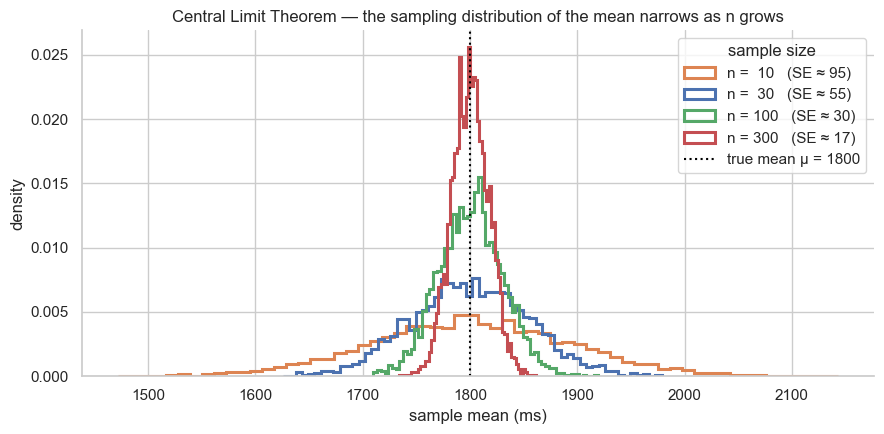

In [7]:
clt_rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(9, 4.5))
for n, color in [(10, "#DD8452"), (30, "#4C72B0"), (100, "#55A868"), (300, "#C44E52")]:
    means = clt_rng.normal(MU, SIGMA, size=(4000, n)).mean(axis=1)
    ax.hist(means, bins=60, density=True, histtype="step", lw=2.2, color=color,
            label=f"n = {n:>3}   (SE ≈ {SIGMA/np.sqrt(n):.0f})")
ax.axvline(MU, color="black", ls=":", lw=1.5, label=f"true mean μ = {MU:.0f}")
ax.set(title="Central Limit Theorem — the sampling distribution of the mean narrows as n grows",
       xlabel="sample mean (ms)", ylabel="density")
ax.legend(title="sample size"); sns.despine(); plt.tight_layout(); plt.show()


> 🧠 **Mental model — the sampling distribution.** Your dataset is *one draw* from a machine that spits out a slightly different sample every time. The **sample mean** is therefore not a fixed fact — it's a *random variable* with its own distribution, centred on the true mean and with spread `SE = σ/√n`. A **confidence interval** is just "the sample mean, ± a couple of standard errors" — a humble admission that the next draw would have landed somewhere nearby. Everything in §4–§8 (CIs, t-tests, sample-size planning) is bookkeeping on top of this one picture.

> ⚠️ **Pitfall.** `SE = σ/√n` assumes your `n` data points are *independent*. If they're correlated — e.g. 100 latency measurements from the *same* user in one burst — your *effective* sample size is far smaller than `n`, the true SE is larger, and your confidence interval is dangerously too narrow. Independence is the assumption that quietly breaks most real-world A/B tests.

In [8]:
def ci_of_mean(data, confidence=0.95):
    """Return (lower, upper) of the confidence interval for the mean."""
    n = len(data)
    mean = np.mean(data)
    sem  = np.std(data, ddof=1) / np.sqrt(n)        # standard error of the mean
    # stats.t.ppf(p, df) is the inverse CDF: the t-value with fraction p of the
    # distribution below it. Here 0.975 gives the ± critical multiplier for 95%.
    crit = stats.t.ppf(0.5 + confidence/2, df=n-1)
    return mean - crit*sem, mean + crit*sem


for name, data in [("Model A", latency_a), ("Model B", latency_b)]:
    lo, hi = ci_of_mean(data, confidence=0.95)
    print(f"{name}:  mean = {data.mean():.1f} ms,  95% CI = [{lo:.1f}, {hi:.1f}]  "
          f"(±{(hi-lo)/2:.1f})")


Model A:  mean = 1790.9 ms,  95% CI = [1754.0, 1827.8]  (±36.9)
Model B:  mean = 2532.2 ms,  95% CI = [2416.1, 2648.3]  (±116.1)


**Three things to notice:**

1. The CIs have half-widths of about 37 ms (Model A) and 116 ms (Model B) — the *uncertainty* on a 200-point mean.
2. The two CIs don't overlap → very strong evidence the means are *actually* different.
3. **Larger samples → narrower CIs.** Halving the half-width takes 4× the data.

> 🎯 **Rule of thumb for fast back-of-envelope CIs:** for n=200 normal-ish data, the half-width is roughly the standard deviation ÷ 7. (Comes from `1.96/sqrt(200) ≈ 0.14`.)

## 5. The t-test — is the difference *real*?

When you measure two things (Model A, Model B) and see different means, you need to know whether the difference is **bigger than the noise**. The classic tool is **Welch's t-test** (the safer of the two t-test flavours — doesn't assume equal variances).

In [9]:
# Two-sample, two-sided Welch's t-test
result = stats.ttest_ind(latency_a, latency_b, equal_var=False)
print(f"t-statistic = {result.statistic:.2f}")
print(f"p-value     = {result.pvalue:.3e}")

# Mean difference and its 95% CI
diff = latency_b.mean() - latency_a.mean()
se = np.sqrt(np.var(latency_a, ddof=1) / len(latency_a) +
             np.var(latency_b, ddof=1) / len(latency_b))
ci_lo, ci_hi = diff - 1.96 * se, diff + 1.96 * se
print(f"\nMean difference (B − A) = {diff:.1f} ms")
print(f"95% CI for the difference: [{ci_lo:.1f}, {ci_hi:.1f}]")


t-statistic = -12.00
p-value     = 2.881e-26

Mean difference (B − A) = 741.4 ms
95% CI for the difference: [620.2, 862.5]


### How to read the output

- **t-statistic ≈ −12** means the difference of means is about 12 standard errors away from zero — *enormous*.
- **p-value ≈ 3×10⁻²⁶** means: *"if the two models actually had the same mean latency, we'd see this big a difference by chance in fewer than 1 in 10²⁵ experiments."*
- **The CI for the difference excludes 0** → the difference is real.

> ⚠️ **Common p-value misunderstandings:**
>
> - p < 0.05 does **not** mean "95% chance the result is real" (a Bayesian probability).
> - p < 0.05 does **not** mean "the difference is important" — it might be 2 ms, statistically significant, and operationally meaningless.
> - p < 0.05 is **not** a free pass: with enough data, *every* tiny difference becomes "significant".
>
> The cure for all three: **always report effect size alongside p-value**.

### 🔬 What a p-value actually is — simulate the null hypothesis

A p-value is the single most misread number in all of statistics. The bullet list above tells you what it is *not*; this section shows you, concretely, what it **is** — by building the exact distribution it's a fraction of.

The precise definition:

> **p-value = the probability of seeing data at least this extreme, *assuming the null hypothesis (H₀) were true*.**

For our two-sample test, H₀ is *"the two models have the same mean latency; any observed difference is pure luck of the draw."* The recipe to turn that abstract sentence into a concrete fraction:

```text
   1.  Assume H₀ is TRUE  →  both groups come from ONE shared distribution.
   2.  Simulate that null world MANY times:
          • shuffle/redraw, split into two groups of the original sizes,
          • compute the test statistic (here: |difference of means|) each time.
   3.  This builds the NULL DISTRIBUTION — the spread of differences
       you'd expect from chance ALONE, if H₀ held.
   4.  p-value = the FRACTION of those null statistics that are
       at least as extreme as the one you ACTUALLY observed.

        null distribution (chance-only differences)
        ▁▂▄▆█████▆▄▂▁
        └────────────┴─────────────────────────────►  | diff of means |
                  ▲                         ▲
              typical chance            YOUR observed diff
              differences               (way out in the tail)
                                        p = area to the right ÷ total
```

If your observed result sits deep in the tail — far beyond what chance alone produces — the fraction is tiny, and you conclude H₀ is an implausible explanation. **A small p-value means "chance alone rarely does this," NOT "H₀ has a small probability of being true."**

In [10]:
# 🔬 PROOF: the p-value IS a fraction of null simulations. Let's compute that
# fraction directly and check it against scipy's analytic t-test p-value.
import numpy as np
from scipy import stats

pv_rng = np.random.default_rng(0)            # seeded → reproducible

# A small, controlled example so the simulation is fast and the story is clear.
group_a = pv_rng.normal(100.0, 15.0, size=40)
group_b = pv_rng.normal(106.0, 15.0, size=40)   # genuinely ~6 units higher

observed_diff = abs(group_a.mean() - group_b.mean())
print(f"Observed |difference of means| = {observed_diff:.2f}\n")

Observed |difference of means| = 11.42



**Simulate the null world — pool, shuffle, re-split many times**

In [11]:
# ── Simulate the NULL world: H0 says both groups share ONE distribution. ──
# Pool every value, then repeatedly shuffle and re-split into 40 + 40.
pooled = np.concatenate([group_a, group_b])
n_a    = len(group_a)
N_NULL = 5000                                # null datasets to generate (modest → <1s)

null_diffs = np.empty(N_NULL)
for i in range(N_NULL):
    pv_rng.shuffle(pooled)                   # destroy any real group structure
    null_diffs[i] = abs(pooled[:n_a].mean() - pooled[n_a:].mean())

**Compare the simulated p-value to scipy's analytic t-test**

In [12]:
# p-value = fraction of the null world at least as extreme as what we saw.
p_simulated = np.mean(null_diffs >= observed_diff)
p_scipy     = stats.ttest_ind(group_a, group_b, equal_var=False).pvalue

print(f"Under H0, a chance |difference| this big or bigger happened in "
      f"{int((null_diffs >= observed_diff).sum())} of {N_NULL} simulations.")
print(f"  p (simulated null fraction) = {p_simulated:.4f}")
print(f"  p (scipy analytic t-test)   = {p_scipy:.4f}")
print(f"\n→ The two agree: the abstract p-value really is just that concrete fraction.")
print(f"→ Typical chance difference ≈ {null_diffs.mean():.2f}; "
      f"ours ({observed_diff:.2f}) sits far out in the tail → small p.")

Under H0, a chance |difference| this big or bigger happened in 5 of 5000 simulations.
  p (simulated null fraction) = 0.0010
  p (scipy analytic t-test)   = 0.0007

→ The two agree: the abstract p-value really is just that concrete fraction.
→ Typical chance difference ≈ 2.76; ours (11.42) sits far out in the tail → small p.


**What a p-value *is*, drawn.** The cell above shuffled the pooled data thousands of times to build the world where H₀ is true. Plot that null distribution and the picture becomes obvious: the **p-value is just the shaded tail** — the fraction of null shuffles that landed at least as far out as what we actually observed.


/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_62602/2494626786.py:8: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  ax.legend(); sns.despine(); plt.tight_layout(); plt.show()
/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


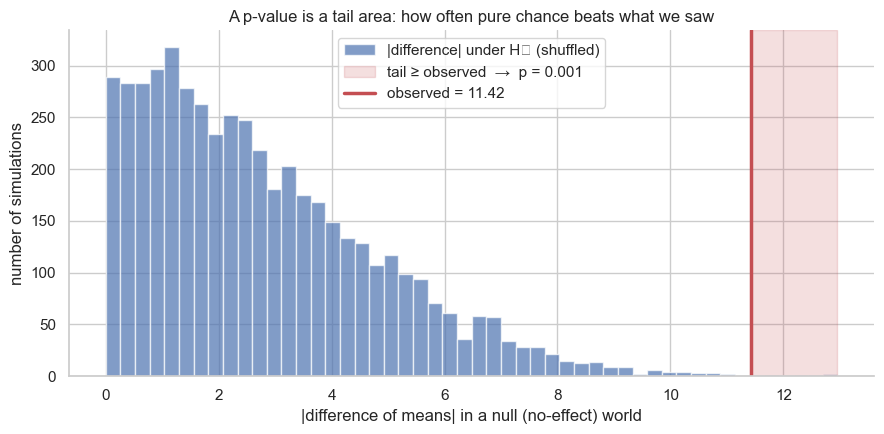

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(null_diffs, bins=50, color="#4C72B0", alpha=0.7, label="|difference| under H₀ (shuffled)")
ax.axvspan(observed_diff, null_diffs.max(), color="#C44E52", alpha=0.18,
           label=f"tail ≥ observed  →  p = {p_simulated:.3f}")
ax.axvline(observed_diff, color="#C44E52", lw=2.5, label=f"observed = {observed_diff:.2f}")
ax.set(title="A p-value is a tail area: how often pure chance beats what we saw",
       xlabel="|difference of means| in a null (no-effect) world", ylabel="number of simulations")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()


**Read the simulation back to the definition, piece by piece:**

| The abstract phrase… | …is this concrete thing in the code |
|---|---|
| "assuming H₀ were true" | pooling both groups and shuffling — erasing any real difference |
| "data at least this extreme" | `null_diffs >= observed_diff` |
| "the probability of seeing…" | the **fraction** of shuffles that cleared that bar (`np.mean(...)`) |
| the test statistic | `|mean(a) − mean(b)|` |

And the three things a p-value is emphatically **NOT**:

- **Not `P(H₀ is true)`.** The simulation *assumes* H₀ and asks how often chance reproduces your data. It never assigns a probability to H₀ itself. (`p = 0.03` does not mean "3% chance the models are equal.")
- **Not the effect size.** A microscopic, irrelevant difference can give a tiny p-value with a big enough `n` — the p-value measures *detectability*, not *importance*. That's exactly why §6 reports Cohen's *d* alongside it.
- **Not a "truth switch" at 0.05.** `p = 0.049` and `p = 0.051` are essentially the same evidence; the 0.05 cutoff is a convention, not a law of nature.

> 🧠 **Mental model — the p-value as a "surprise meter for the null."** Picture a world where H₀ is true and the only thing generating differences is luck. The p-value answers: *"how often does that luck-only world produce something at least as extreme as what I actually saw?"* High p → "happens all the time, no surprise, chance is a fine explanation." Low p → "chance almost never does this, so chance is a poor explanation — something real may be going on." You never learn `P(H₀ is true)`; you only learn how *surprising* your data is **if** H₀ held. Pair that surprise with an effect size (§6) and you have the full story: *is it real* **and** *is it big*.

## 6. Effect size — the number managers care about

The p-value tells you whether a difference is real. **Cohen's *d*** tells you how *big* the difference is, in units of the natural spread of the data.

$$d = \frac{\bar{x}_B - \bar{x}_A}{s_\text{pooled}}$$

| Cohen's *d* | Rough label |
|---|---|
| 0.2 | small |
| 0.5 | medium |
| 0.8 | large |
| > 1.0 | very large |

In [14]:
def cohens_d(x, y):
    """Cohen's d for two independent samples."""
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(y) - np.mean(x)) / pooled


d = cohens_d(latency_a, latency_b)
print(f"Cohen's d = {d:+.2f}")
print(f"Mean diff = {latency_b.mean() - latency_a.mean():.0f} ms")


Cohen's d = +1.20
Mean diff = 741 ms


**How to report this to a manager:**

> *"Model B is roughly 740 ms slower than Model A on average (Cohen's d ≈ 1.2, very large effect). 95% CI for the difference: [620, 863] ms. p ≈ 3×10⁻²⁶."*

The numbers in **bold below** are the ones the manager will remember:

- **how big** is the difference (Cohen's d, mean diff)
- **how sure** are we (CI, p-value)
- **what does it mean in their units** (740 ms — would users notice?)

## 7. Sample size — how much data do I need?

Before you run a 10,000-user A/B test, ask: *"what's the smallest sample that would let me detect the effect I care about, with 80% power, at significance 0.05?"*

The formula (for two equal groups, two-sided t-test, normal data) is roughly:

$$n \approx \frac{16}{d^2}$$

per group, where `d` is the *minimum* effect size you'd care about.

In [15]:
def sample_size_for_d(d, alpha=0.05, power=0.80):
    """Approximate per-group sample size to detect Cohen's d with given power."""
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta  = stats.norm.ppf(power)
    return int(np.ceil(2 * ((z_alpha + z_beta) / d) ** 2))


print(f"{'effect':>8}  {'per-group n':>12}")
for d in [0.1, 0.2, 0.5, 0.8, 1.0]:
    n = sample_size_for_d(d)
    print(f"  d = {d:.1f}    {n:>10,}")


  effect   per-group n
  d = 0.1         1,570
  d = 0.2           393
  d = 0.5            63
  d = 0.8            25
  d = 1.0            16


**The table as a curve — and why small effects are so expensive.** Required sample size scales like 1/d², so halving the effect you want to detect *quadruples* the data you need. On a log axis the cliff is unmistakable.


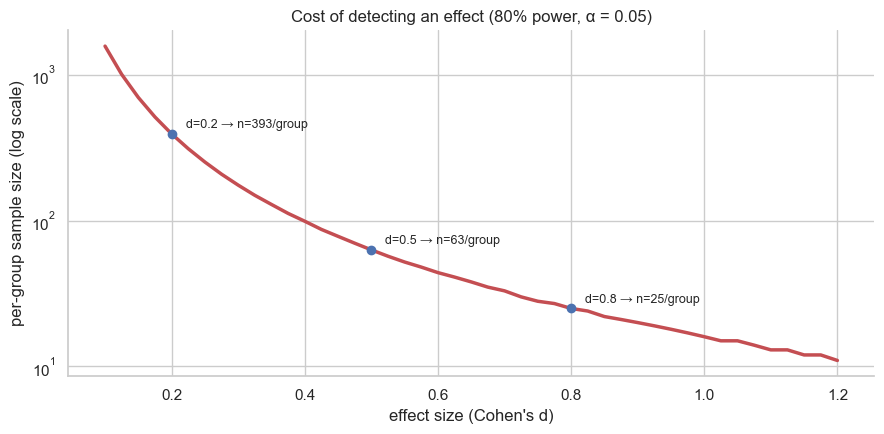

In [16]:
ds = np.linspace(0.1, 1.2, 45)
ns = [sample_size_for_d(d) for d in ds]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ds, ns, lw=2.5, color="#C44E52")
for d in [0.2, 0.5, 0.8]:
    nd = sample_size_for_d(d)
    ax.plot(d, nd, "o", color="#4C72B0")
    ax.annotate(f"d={d} → n={nd:,}/group", (d, nd), textcoords="offset points",
                xytext=(10, 4), fontsize=9)
ax.set_yscale("log")
ax.set(title="Cost of detecting an effect (80% power, α = 0.05)",
       xlabel="effect size (Cohen's d)", ylabel="per-group sample size (log scale)")
sns.despine(); plt.tight_layout(); plt.show()


**The big takeaway.** Tiny effects need *enormous* samples. If you can only run 200 users per arm, you can reliably detect a Cohen's d of about 0.3 — but anything smaller will hide in the noise.

> 💡 **Sample-size planning prevents the silent failure** where you ran a test, the p-value was 0.12, and you concluded "no effect" — when you actually just didn't have enough data.

## 8. A complete A/B-test report

The "good" version of A/B reporting puts all five numbers a manager wants on one screen:

In [17]:
def ab_report(name_a, x, name_b, y, alpha=0.05):
    """Print a five-number A/B summary that's safe to send to a manager."""
    n_a, n_b   = len(x), len(y)
    mean_a, mean_b = np.mean(x), np.mean(y)
    diff       = mean_b - mean_a
    var_a, var_b = np.var(x, ddof=1)/n_a, np.var(y, ddof=1)/n_b
    se_diff    = np.sqrt(var_a + var_b)
    # Welch–Satterthwaite df, so the CI uses the SAME t-distribution as the
    # Welch p-value below — otherwise the CI and the p-value could disagree.
    df_welch   = (var_a + var_b)**2 / (var_a**2/(n_a-1) + var_b**2/(n_b-1))
    t_crit     = stats.t.ppf(1 - alpha/2, df_welch)
    ci_lo, ci_hi = diff - t_crit*se_diff, diff + t_crit*se_diff
    d          = cohens_d(x, y)
    p_val      = stats.ttest_ind(x, y, equal_var=False).pvalue

    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f" A/B test: {name_a}  vs  {name_b}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f" Sample sizes      : {n_a} vs {n_b}")
    print(f" Mean              : {mean_a:.1f}  vs  {mean_b:.1f}")
    print(f" Difference (B−A)  : {diff:+.1f}")
    print(f" 95% CI for diff   : [{ci_lo:+.1f}, {ci_hi:+.1f}]")
    print(f" Cohen's d         : {d:+.2f}     (effect size)")
    print(f" p-value           : {p_val:.2e}")
    verdict = "REAL difference" if p_val < alpha and abs(d) > 0.2 \
              else "NOT meaningfully different"
    print(f" Verdict           : {verdict}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")


ab_report("Model A", latency_a, "Model B", latency_b)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 A/B test: Model A  vs  Model B
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Sample sizes      : 200 vs 200
 Mean              : 1790.9  vs  2532.2
 Difference (B−A)  : +741.4
 95% CI for diff   : [+619.6, +863.1]
 Cohen's d         : +1.20     (effect size)
 p-value           : 2.88e-26
 Verdict           : REAL difference
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


**Why this template works.**

- **Sample sizes** show whether the test was powered enough to trust the verdict.
- **Means + difference + CI** answer "by how much?" — the manager's first question.
- **Cohen's d** answers "is the difference *big* in real-world terms?" — the second question.
- **p-value** answers "is it real?" — the third question.
- The **verdict** combines the two ("real *and* meaningful"), preventing the common mistake of acting on a statistically significant but operationally tiny effect.

## 9. The three classical mistakes (and the fixes)

| Mistake | What happens | Fix |
|---|---|---|
| **Peeking** — running a test, looking at the p-value daily, stopping the first time it dips below 0.05 | False positives explode. With 5 peeks the *actual* false-positive rate is around 20%, not 5%. | Plan the sample size in advance. Stop *only* at that pre-planned moment. |
| **Multiple comparisons** — running 20 t-tests on 20 metrics, declaring the one with p<0.05 as a "win" | At alpha=0.05 you expect 1 false positive per 20 tests by definition. | Use Bonferroni (alpha/k) or false-discovery-rate correction. Or: pre-register your hypothesis. |
| **Reporting only p, not d** | Statistically significant but operationally meaningless effects get shipped. | Always report effect size alongside p-value. |

## 🧪 Practice exercises

### Exercise 1 — ⭐ Robust statistics on a heavy-tailed metric

Compute the **mean**, **median**, **5%-trimmed mean**, and **standard deviation** of `latency_b`. Which one would you report to a manager who asks "what's a typical latency?".

In [18]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from scipy.stats import trim_mean

print(f"mean              = {np.mean(latency_b):.1f}")
print(f"median            = {np.median(latency_b):.1f}")
print(f"5%-trimmed mean   = {trim_mean(latency_b, 0.05):.1f}")
print(f"std               = {np.std(latency_b, ddof=1):.1f}")
```

The **median** is usually the most honest "typical user" number on a right-skewed
metric like latency. The mean and std are dragged up by the slow tail. The
trimmed mean (drop the top and bottom 5% before averaging) is a robust compromise.
</details>

### Exercise 2 — ⭐⭐ Confidence interval, by hand

Without using `stats.t.ppf`, compute an *approximate* 95% CI for the mean of `latency_a` using the rule of thumb `mean ± 1.96 × std/√n`. Compare with the t-distribution-based CI from §4.

In [19]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
n = len(latency_a)
mean = latency_a.mean()
sem  = latency_a.std(ddof=1) / np.sqrt(n)

print(f"Normal-approx CI :  [{mean - 1.96*sem:.1f},  {mean + 1.96*sem:.1f}]")
print(f"t-distribution CI:  [{ci_of_mean(latency_a)[0]:.1f},  {ci_of_mean(latency_a)[1]:.1f}]")
```

For n=200 the two are almost identical (the t-distribution converges to normal as n grows). For n<30 the t-distribution CI is noticeably wider — which is exactly why people invented it.
</details>

### Exercise 3 — ⭐⭐ Sample size planning

You want to detect a **0.3 effect size** with 90% power and significance 0.05. How many users per arm do you need? What if you can tolerate 80% power instead?

In [20]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
print(f"d = 0.3, power = 0.80 → n = {sample_size_for_d(0.3, power=0.80):,} per arm")
print(f"d = 0.3, power = 0.90 → n = {sample_size_for_d(0.3, power=0.90):,} per arm")
print(f"d = 0.5, power = 0.80 → n = {sample_size_for_d(0.5, power=0.80):,} per arm")
```

Doubling the power from 80% to 90% requires ~30% more data — a real cost. The
practical takeaway: 80% power is the standard convention for a reason; pushing
to 90% costs a lot of users.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The snippet below is supposed to compute the standard error of the mean, but the answer is consistently a factor of √n too small. Find the bug.

```python
def sem_buggy(data):
    return np.std(data, ddof=1) * np.sqrt(len(data))
```

In [21]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Your fixed version  👇


<details>
<summary>💡 <b>Solution</b></summary>

The formula for the *standard error of the mean* is `σ / √n`, not `σ × √n`.

```python
def sem(data):
    return np.std(data, ddof=1) / np.sqrt(len(data))
```

Sanity check: as `n` grows, the standard error should *shrink* (we're more sure of the mean). The buggy version grows instead — the immediate signal that the formula is upside down.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Paired-samples t-test

Simulate 30 customers measured *before* and *after* a UX change. The change made each customer ~5% more satisfied. Run a **paired-samples t-test** (`stats.ttest_rel`) and compare with the unpaired version. Which is more powerful, and why?


In [22]:
# Your code here  👇
rng = np.random.default_rng(0)


<details>
<summary>💡 <b>Solution</b></summary>

```python
rng = np.random.default_rng(0)
before = rng.normal(3.8, 0.5, 30)
after  = before * 1.05 + rng.normal(0, 0.05, 30)

paired   = stats.ttest_rel(before,  after)
unpaired = stats.ttest_ind(before,  after, equal_var=False)

print(f"Paired   t = {paired.statistic:.2f}, p = {paired.pvalue:.4f}")
print(f"Unpaired t = {unpaired.statistic:.2f}, p = {unpaired.pvalue:.4f}")
```

**Why paired is more powerful.** When the same *customer* is
measured twice, customer-level baseline noise cancels out. The
paired test removes that noise from the denominator → larger
t-statistic → smaller p-value for the same true effect. Use the
paired test whenever you have natural pairs (before/after,
A vs B on the same query, etc.).

</details>

### Stretch exercise B — ⭐⭐⭐ Bootstrap confidence interval for the median

The formulas in this notebook give CIs for the *mean*. Implement a **bootstrap CI for the median** (resample with replacement, take the 2.5th / 97.5th percentile of the bootstrap medians). Test on a heavy-tailed sample.


<details>
<summary>💡 <b>Solution</b></summary>

```python
def boot_ci_median(data, n_boot=2000, ci=0.95, rng=None):
    rng = rng or np.random.default_rng(0)
    n   = len(data)
    meds = np.array([np.median(rng.choice(data, n, replace=True))
                      for _ in range(n_boot)])
    alpha = (1 - ci) / 2
    return float(np.median(data)), float(np.quantile(meds, alpha)), float(np.quantile(meds, 1 - alpha))


# Heavy-tailed sample
sample = np.concatenate([np.random.default_rng(0).normal(2, 0.5, 95),
                          np.random.default_rng(1).normal(8, 1.0, 5)])
point, lo, hi = boot_ci_median(sample)
print(f"Median = {point:.2f}   95% CI = [{lo:.2f}, {hi:.2f}]")
```

**Bootstrap is the Swiss-army knife of statistics.** No formula
needed — just resample and measure. Same approach works for any
statistic: trimmed mean, 95th percentile, Gini coefficient, etc.

</details>

### Stretch exercise C — ⭐⭐⭐ Permutation test for the difference of two means

Instead of assuming the data is normal (which is what a t-test does), a **permutation test** estimates the p-value purely from the data. The procedure:

1. Compute the observed difference of means `obs = mean(a) - mean(b)`.
2. Pool `a` and `b`, then repeatedly shuffle and re-split into two groups of the original sizes.
3. The p-value is the fraction of shuffled differences whose absolute value is ≥ `|obs|`.

Test on:

```python
rng = np.random.default_rng(0)
a = rng.normal(loc=10.5, scale=2.0, size=50)
b = rng.normal(loc=10.0, scale=2.0, size=50)
```

Use 2,000 permutations and report `obs`, the p-value, and how it compares to a Welch's t-test on the same data.

In [23]:
# Your code here  👇
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)
a = rng.normal(loc=10.5, scale=2.0, size=50)
b = rng.normal(loc=10.0, scale=2.0, size=50)

def permutation_p_value(a, b, n_iter=2_000, rng=None):
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)
a = rng.normal(loc=10.5, scale=2.0, size=50)
b = rng.normal(loc=10.0, scale=2.0, size=50)

def permutation_p_value(a, b, n_iter=2_000, rng=None):
    rng = rng or np.random.default_rng(0)
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    n_a = len(a)
    count = 0
    for _ in range(n_iter):
        rng.shuffle(pooled)
        diff = pooled[:n_a].mean() - pooled[n_a:].mean()
        if abs(diff) >= abs(obs):
            count += 1
    return obs, count / n_iter

obs, p_perm = permutation_p_value(a, b)
t, p_welch = stats.ttest_ind(a, b, equal_var=False)
print(f"observed difference: {obs:.3f}")
print(f"permutation p-value: {p_perm:.4f}")
print(f"Welch t-test p-value: {p_welch:.4f}")
```

**Reasoning.** Three things worth absorbing. (1) **Permutation tests make no distributional assumptions** — they only assume the two groups are *exchangeable under the null hypothesis*. That's a much weaker assumption than 'normally distributed' and is robust to outliers and skew. (2) The p-value is *literally* the fraction of shuffles that look at least as extreme as what you observed — it has an intuitive frequency interpretation, no Student-t tables required. (3) For roughly-normal data the permutation p-value and Welch's p-value will agree closely; the divergence appears with heavy tails and skew, where the permutation test is the more honest answer.
</details>

### Stretch exercise D — ⭐⭐⭐ Two-sample t-test from summary stats

Often you have only group summaries, not raw data. Implement Welch's t-test (unequal variances) given the **means, standard deviations, and counts** of two groups, and report the p-value.

Test data:

```python
x1, s1, n1 = 100.0, 12.0, 50
x2, s2, n2 = 105.0, 14.0, 60
```

In [24]:
# Your code here  👇
import math
from scipy import stats

x1, s1, n1 = 100.0, 12.0, 50
x2, s2, n2 = 105.0, 14.0, 60

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import math
from scipy import stats

x1, s1, n1 = 100.0, 12.0, 50
x2, s2, n2 = 105.0, 14.0, 60

se = math.sqrt(s1**2/n1 + s2**2/n2)
t  = (x1 - x2) / se

# Welch–Satterthwaite degrees of freedom
num  = (s1**2/n1 + s2**2/n2) ** 2
den  = (s1**2/n1)**2 / (n1 - 1) + (s2**2/n2)**2 / (n2 - 1)
df   = num / den

p_two_sided = 2 * stats.t.sf(abs(t), df)
print(f"t = {t:.3f}  df = {df:.2f}  p = {p_two_sided:.4f}")
```

**Reasoning.** This is the calculation `scipy.stats.ttest_ind_from_stats` does for you — but writing it once builds the right intuition. Three points. (1) Welch's formula doesn't pool the variances, which is what makes it robust to unequal variances and unequal `n`. (2) The **Welch–Satterthwaite** degrees-of-freedom approximation is the messy fraction in the middle; you almost never compute it by hand outside of textbook exercises. (3) `stats.t.sf(...)` is the *survival function* (1 − CDF), which is more numerically stable than `1 - stats.t.cdf(...)` in the tails — useful when p is tiny.
</details>

## 🎁 Bonus mini-project — Power analysis dashboard

Write a function `power_table(d_values, n_values)` that returns a DataFrame showing the statistical power (probability of detecting an effect of size `d` at significance 0.05) for every combination of effect size and sample size.

Use it to answer: "what's the smallest sample I need to have 80% power for a 0.5 effect size?".

In [25]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def power_for(d, n, alpha=0.05):
    """Approximate power of a two-sample, two-sided t-test."""
    z_alpha = stats.norm.ppf(1 - alpha/2)
    # Non-centrality parameter
    ncp = d * np.sqrt(n / 2)
    return 1 - stats.norm.cdf(z_alpha - ncp) + stats.norm.cdf(-z_alpha - ncp)


def power_table(d_values, n_values):
    rows = []
    for d in d_values:
        rows.append({"d": d,
                     **{f"n={n}": round(power_for(d, n), 2) for n in n_values}})
    return pd.DataFrame(rows).set_index("d")


tbl = power_table([0.1, 0.2, 0.3, 0.5, 0.8],
                  [50, 100, 200, 500, 1000])
print(tbl)
```

You can read the table directly: each cell is the probability that you'd
detect the effect *if it's really there*. Use it to plan experiments without
running 100 simulations.
</details>

## 🧠 Key takeaways

1. **Plot before you summarise.** Histograms and box plots tell you the shape; means and standard deviations don't.
2. For **skewed or heavy-tailed** data, report median and percentiles (p50, p95, p99) *alongside* the mean.
3. A **confidence interval** turns a point estimate into honest uncertainty. The half-width shrinks with √n, so doubling precision needs 4× the data.
4. A **t-test** answers "is the difference real?". An **effect size** (Cohen's *d*) answers "is it big?". You need both.
5. **Sample-size planning** prevents the silent failure of an underpowered test.
6. The three classical mistakes are **peeking, multiple comparisons, and reporting only p**. The fixes are pre-registration, correction, and effect size.
7. Every A/B report you ship should have: sample sizes, means, difference + CI, Cohen's *d*, p-value, *and* a verdict.

## ✅ Self-assessment

- [ ] Plot a histogram + box plot and explain skewness, tails, outliers
- [ ] Compute mean, median, p95, p99 for a sample
- [ ] Compute a 95% CI for a mean
- [ ] Run a Welch's t-test and correctly interpret the p-value
- [ ] Compute and interpret Cohen's d
- [ ] Plan a sample size for a target effect size and power
- [ ] Spot the three classical A/B mistakes

## 🚀 Next step

Continue with **Notebook 11 — Time Series and Forecasting**, where the statistics you just learned become the backbone of evaluating forecasts honestly.